<a href="https://colab.research.google.com/github/samirmh/trading/blob/main/stocks_single_stock_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [15]:

!pip install yfinance
import yfinance as yf
import pandas as pd
import numpy as np

In [16]:
# Define the ticker symbol
ticker_symbol = 'NVDA'

# Download daily stock price data for the defined period
stock_data = yf.download(ticker_symbol, start='2024-08-10', end='2026-08-10', interval='1d')

# Display the data
stock_data

/tmp/ipykernel_4019/905348191.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download(ticker_symbol, start='2024-08-10', end='2026-08-10', interval='1d')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA
Date,,,,,
2024-08-12,108.840607,110.887237,106.085154,106.145053,325559900
2024-08-13,115.948883,116.038739,111.396389,112.254975,312646700
2024-08-14,117.885704,118.404845,113.882300,118.334961,339246400
2024-08-15,122.657829,123.037201,117.276699,118.564578,318086700
2024-08-16,124.374992,124.794299,120.980586,121.739337,302589900
...,...,...,...,...,...
2026-08-03,206.639999,208.740005,196.850006,197.690002,128406900
2026-08-04,211.940002,213.059998,209.050003,211.300003,134922000


In [17]:
stock_data.to_csv('stock_data.csv')

In [18]:
# this is daily stock data. the fields are open = open price on the day, high = high price on the day, low = low price on the day, close = close price on the day, adj close = adjusted close price on the day, volume = volume on the day

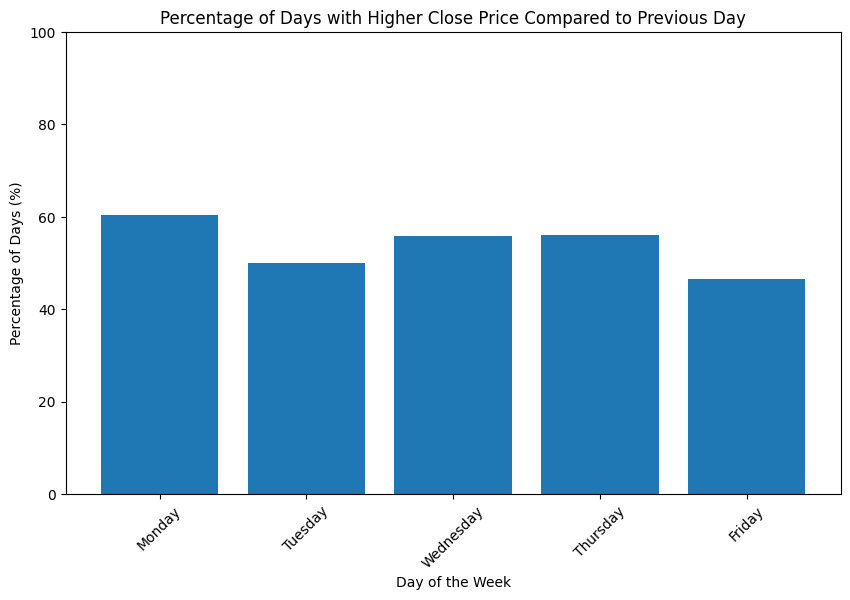

In [19]:
# Can you create a bar chart with the days of the week on the x-axis and the percent of days where the close price is above the close price of the previous day on the y-axis
# First, convert the Index ('Date') to a datetime format and extract the day of the week
stock_data.index = pd.to_datetime(stock_data.index)
stock_data['Day_of_Week'] = stock_data.index.day_name()

# Create a column that shows whether the close price is higher than the previous day
stock_data['Close_Higher'] = stock_data['Close'] > stock_data['Close'].shift(1)

# Group by the day of the week and calculate the percentage of days where the close price was higher than the previous day
percent_higher_close = stock_data.groupby('Day_of_Week')['Close_Higher'].mean() * 100

# Sort the days of the week in order
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday']
percent_higher_close = percent_higher_close.reindex(day_order)

# Now, let's create a bar chart
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(percent_higher_close.index, percent_higher_close)
plt.title('Percentage of Days with Higher Close Price Compared to Previous Day')
plt.xlabel('Day of the Week')
plt.ylabel('Percentage of Days (%)')
plt.ylim(0, 100)  # Set the y-axis to range from 0 to 100 for percentage
plt.xticks(rotation=45)
plt.show()

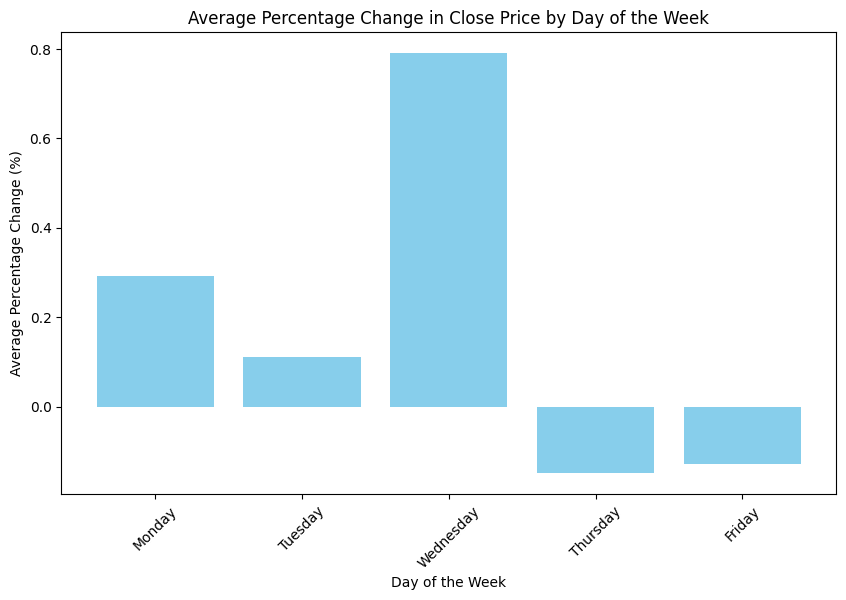

In [20]:
# Can you create a bar chart with the days of the week on the x-axis and the average percentage change of the close price compared to the previous day close price on the y-axis
# Calculate the percentage change in close price compared to the previous day
stock_data['Pct_Change_Close'] = stock_data['Close'].pct_change() * 100

# Group by the day of the week and calculate the average percentage change
avg_pct_change = stock_data.groupby('Day_of_Week')['Pct_Change_Close'].mean()

# Reindex the days of the week to ensure they are in order
avg_pct_change = avg_pct_change.reindex(day_order)

# Create a bar chart for the average percentage change in close price
plt.figure(figsize=(10, 6))
plt.bar(avg_pct_change.index, avg_pct_change, color='skyblue')
plt.title('Average Percentage Change in Close Price by Day of the Week')
plt.xlabel('Day of the Week')
plt.ylabel('Average Percentage Change (%)')
plt.xticks(rotation=45)
plt.show()

In [21]:
# What is the average length of rallies in days? With a rally defined as closing price greater than the previous day closing price

# To calculate the average length of rallies, we need to find consecutive sequences where the close price is greater than the previous day.

# Create a new column indicating the start of a rally (where the close price is greater than the previous day)
stock_data['Rally'] = stock_data['Close'] > stock_data['Close'].shift(1)

# Calculate the lengths of consecutive "True" values in the 'Rally' column
rally_lengths = []
current_rally_length = 0

for rally in stock_data['Rally']:
    if rally:
        current_rally_length += 1
    else:
        if current_rally_length > 0:
            rally_lengths.append(current_rally_length)
        current_rally_length = 0

# If the last sequence was a rally, append its length
if current_rally_length > 0:
    rally_lengths.append(current_rally_length)

# Calculate the average length of rallies
average_rally_length = sum(rally_lengths) / len(rally_lengths) if rally_lengths else 0

average_rally_length

2.0150375939849625

In [22]:
# What is the average length of downturns in days? With a downturn defined as closing price less than the previous day closing price

# Similar to rallies, we now calculate the length of downturns (where the close price is less than the previous day's close)

# Create a new column indicating the start of a downturn (where the close price is less than the previous day)
stock_data['Downturn'] = stock_data['Close'] < stock_data['Close'].shift(1)

# Calculate the lengths of consecutive "True" values in the 'Downturn' column
downturn_lengths = []
current_downturn_length = 0

for downturn in stock_data['Downturn']:
    if downturn:
        current_downturn_length += 1
    else:
        if current_downturn_length > 0:
            downturn_lengths.append(current_downturn_length)
        current_downturn_length = 0

# If the last sequence was a downturn, append its length
if current_downturn_length > 0:
    downturn_lengths.append(current_downturn_length)

# Calculate the average length of downturns
average_downturn_length = sum(downturn_lengths) / len(downturn_lengths) if downturn_lengths else 0

average_downturn_length

1.7424242424242424

In [23]:
# What is the correlation between volume and close price?

# Calculate the correlation between Volume and Close price
correlation_volume_close = stock_data[('Volume', 'NVDA')].corr(stock_data[('Close', 'NVDA')])

correlation_volume_close

np.float64(-0.5990430983284585)

In [24]:
def binary_indicators(df):
    # Calculate previous day's prices for comparison
    prev_close = df['Close'].shift(1)
    prev_open = df['Open'].shift(1)
    prev_high = df['High'].shift(1)
    prev_low = df['Low'].shift(1)
    prev_volume = df['Volume'].shift(1)

    # 1. close_higher_than_prev_close: close greater than previous day close
    df['close_higher_than_prev_close'] = (df['Close'] > prev_close).astype(int)

    # 2. close_lower_than_prev_close: close less than or equal to previous day close
    df['close_lower_than_prev_close'] = (df['Close'] <= prev_close).astype(int)

    # 3. open_higher_than_prev_close: open greater than previous day close
    df['open_higher_than_prev_close'] = (df['Open'] > prev_close).astype(int)

    # 4. open_lower_than_prev_close: open less than or equal to previous day close
    df['open_lower_than_prev_close'] = (df['Open'] <= prev_close).astype(int)

    # 5. close_higher_than_open: open less than or equal to previous day close
    df['close_higher_than_open'] = (df['Close'] > df['Open']).astype(int)

    # 6. low_lower_than_prev_close: open less than or equal to previous day close
    df['low_lower_than_prev_close'] = (df['Low'] <= prev_close).astype(int)

    # 7. close_lower_than_prev_low: close less than or equal to previous day close
    df['close_lower_than_prev_low'] = (df['Close'] <= prev_low).astype(int)

    return df

# Apply the function to the existing stock_data
stock_data = binary_indicators(stock_data)

# Display the results
display(stock_data[['Open', 'Close', 'High', 'Low', 'Volume', 'close_higher_than_prev_close', 'close_lower_than_prev_close', 'open_higher_than_prev_close', 'open_lower_than_prev_close', 'close_higher_than_open', 'low_lower_than_prev_close', 'close_lower_than_prev_low']].tail())

Price,Open,Close,High,Low,Volume,close_higher_than_prev_close,close_lower_than_prev_close,open_higher_than_prev_close,open_lower_than_prev_close,close_higher_than_open,low_lower_than_prev_close,close_lower_than_prev_low
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,,,,
Date,,,,,,,,,,,,
2026-08-03,197.690002,206.639999,208.740005,196.850006,128406900,1,0,0,1,1,1,0
2026-08-04,211.300003,211.940002,213.059998,209.050003,134922000,1,0,1,0,1,0,0
2026-08-05,216.860001,219.220001,222.220001,216.399994,158187400,1,0,1,0,1,0,0
2026-08-06,221.529999,218.990005,223.630005,217.000000,113940600,0,1,1,0,0,1,0
2026-08-07,221.539993,223.960007,224.759995,220.660004,105669400,1,0,1,0,1,0,0


In [25]:
stock_data.head()

Price,Close,High,Low,Open,Volume,Day_of_Week,Close_Higher,Pct_Change_Close,Rally,Downturn,close_higher_than_prev_close,close_lower_than_prev_close,open_higher_than_prev_close,open_lower_than_prev_close,close_higher_than_open,low_lower_than_prev_close,close_lower_than_prev_low
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,
2024-08-12,108.840607,110.887237,106.085154,106.145053,325559900,Monday,False,NaN,False,False,0,0,0,0,1,0,0
2024-08-13,115.948883,116.038739,111.396389,112.254975,312646700,Tuesday,True,6.530905,True,False,1,0,1,0,1,0,0
2024-08-14,117.885704,118.404845,113.882300,118.334961,339246400,Wednesday,True,1.670409,True,False,1,0,1,0,0,1,0
2024-08-15,122.657829,123.037201,117.276699,118.564578,318086700,Thursday,True,4.048095,True,False,1,0,1,0,1,1,0
2024-08-16,124.374992,124.794299,120.980586,121.739337,302589900,Friday,True,1.399962,True,False,1,0,0,1,1,1,0


In [28]:
def fifty_two_week_indicators(df):
    # Calculate the 52-week (approximately 252 trading days) rolling max and min of the 'Close' price
    current_52_week_high = df['Close'].rolling(window=252, min_periods=1).max()
    current_52_week_low = df['Close'].rolling(window=252, min_periods=1).min()

    # new_52_week_high: 1 if current close is a new 52-week high, 0 otherwise
    df['new_52_week_high'] = (df['Close'] > current_52_week_high).astype(int)

    # new_52_week_low: 1 if current close is a new 52-week low, 0 otherwise
    df['new_52_week_low'] = (df['Close'] < current_52_week_low).astype(int)

    return df

# Apply the function to the existing stock_data
stock_data = fifty_two_week_indicators(stock_data)

# Display the results with the new columns
display(stock_data[['Close', 'new_52_week_high', 'new_52_week_low']].tail())

Price,Close,new_52_week_high,new_52_week_low
Ticker,NVDA,,
Date,,,
2026-08-03,206.639999,0,0
2026-08-04,211.940002,0,0
2026-08-05,219.220001,0,0
2026-08-06,218.990005,0,0
2026-08-07,223.960007,0,0


In [29]:
def day_of_week_binary_indicators(df):
    # Ensure 'Day_of_Week' column exists (it should from previous steps)
    if 'Day_of_Week' not in df.columns:
        df.index = pd.to_datetime(df.index)
        df['Day_of_Week'] = df.index.day_name()

    days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    for day in days:
        df[f'is_{day.lower()}'] = (df['Day_of_Week'] == day).astype(int)
    return df

# Apply the function to the existing stock_data
stock_data = day_of_week_binary_indicators(stock_data)

# Display the results with the new columns
display(stock_data[['Day_of_Week', 'is_monday', 'is_tuesday', 'is_wednesday', 'is_thursday', 'is_friday', 'is_saturday', 'is_sunday']].tail())

Price,Day_of_Week,is_monday,is_tuesday,is_wednesday,is_thursday,is_friday,is_saturday,is_sunday
Ticker,,,,,,,,
Date,,,,,,,,
2026-08-03,Monday,1,0,0,0,0,0,0
2026-08-04,Tuesday,0,1,0,0,0,0,0
2026-08-05,Wednesday,0,0,1,0,0,0,0
2026-08-06,Thursday,0,0,0,1,0,0,0
2026-08-07,Friday,0,0,0,0,1,0,0


In [30]:
def daily_percent_change(df):
    # Calculate the percentage change in 'Close' price compared to the previous day
    df['daily_pct_change'] = df['Close'].pct_change() * 100
    return df

# Apply the function to the existing stock_data
stock_data = daily_percent_change(stock_data)

# Display the results with the new column
display(stock_data[['Close', 'daily_pct_change']].head())

Price,Close,daily_pct_change
Ticker,NVDA,
Date,,
2024-08-12,108.840607,NaN
2024-08-13,115.948883,6.530905
2024-08-14,117.885704,1.670409
2024-08-15,122.657829,4.048095
2024-08-16,124.374992,1.399962


In [36]:
def daily_pct_change_binary_indicators(df):
    # Ensure daily_pct_change exists
    if 'daily_pct_change' not in df.columns:
        df['daily_pct_change'] = df['Close'].pct_change() * 100

    pct = df['daily_pct_change']

    # Positive percentage change indicators
    df['plus_1_pct'] = ((pct >= 1) & (pct < 2)).astype(int)
    df['plus_2_pct'] = ((pct >= 2) & (pct < 3)).astype(int)
    df['plus_3_pct'] = ((pct >= 3) & (pct < 4)).astype(int)
    df['plus_4_pct'] = ((pct >= 4) & (pct < 5)).astype(int)
    df['plus_5_pct'] = ((pct >= 5) & (pct < 6)).astype(int)
    df['plus_6_or_more_pct'] = (pct >= 6).astype(int)

    # Negative percentage change indicators
    df['minus_1_pct'] = ((pct <= -1) & (pct > -2)).astype(int)
    df['minus_2_pct'] = ((pct <= -2) & (pct > -3)).astype(int)
    df['minus_3_pct'] = ((pct <= -3) & (pct > -4)).astype(int)
    df['minus_4_pct'] = ((pct <= -4) & (pct > -5)).astype(int)
    df['minus_5_pct'] = ((pct <= -5) & (pct > -6)).astype(int)
    df['minus_6_or_more_pct'] = (pct <= -6).astype(int)

    return df

# Apply the function to the existing stock_data
stock_data = daily_pct_change_binary_indicators(stock_data)

In [35]:
stock_data.head()

Price,Close,High,Low,Open,Volume,Day_of_Week,Close_Higher,Pct_Change_Close,Rally,Downturn,...,plus_3_pct,plus_4_pct,plus_5_pct,plus_6_or_more_pct,minus_1_pct,minus_2_pct,minus_3_pct,minus_4_pct,minus_5_pct,minus_6_or_more_pct
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,,,,,...,,,,,,,,,,
Date,,,,,,,,,,,,,,,,,,,,,
2024-08-12,108.840607,110.887237,106.085154,106.145053,325559900,Monday,False,NaN,False,False,...,0,0,0,0,0,0,0,0,0,0
2024-08-13,115.948883,116.038739,111.396389,112.254975,312646700,Tuesday,True,6.530905,True,False,...,0,0,0,1,0,0,0,0,0,0
2024-08-14,117.885704,118.404845,113.882300,118.334961,339246400,Wednesday,True,1.670409,True,False,...,0,0,0,0,0,0,0,0,0,0
2024-08-15,122.657829,123.037201,117.276699,118.564578,318086700,Thursday,True,4.048095,True,False,...,0,1,0,0,0,0,0,0,0,0
2024-08-16,124.374992,124.794299,120.980586,121.739337,302589900,Friday,True,1.399962,True,False,...,0,0,0,0,0,0,0,0,0,0


In [37]:
def pct_diff_from_52_week_high(df):
    # Calculate the 52-week (approx 252 trading days) rolling max of the 'Close' price
    high_52_week = df['Close'].rolling(window=252, min_periods=1).max()

    # Calculate the percentage difference from the 52-week high
    # This value will be 0 when the price is at the high, and negative otherwise.
    df['pct_diff_52w_high'] = ((df['Close'] - high_52_week) / high_52_week) * 100

    return df

# Apply the function to the existing stock_data
stock_data = pct_diff_from_52_week_high(stock_data)

# Display the results
display(stock_data[['Close', 'pct_diff_52w_high']].tail())

Price,Close,pct_diff_52w_high
Ticker,NVDA,
Date,,
2026-08-03,206.639999,-12.241949
2026-08-04,211.940002,-9.991088
2026-08-05,219.220001,-6.899342
2026-08-06,218.990005,-6.997019
2026-08-07,223.960007,-4.886306


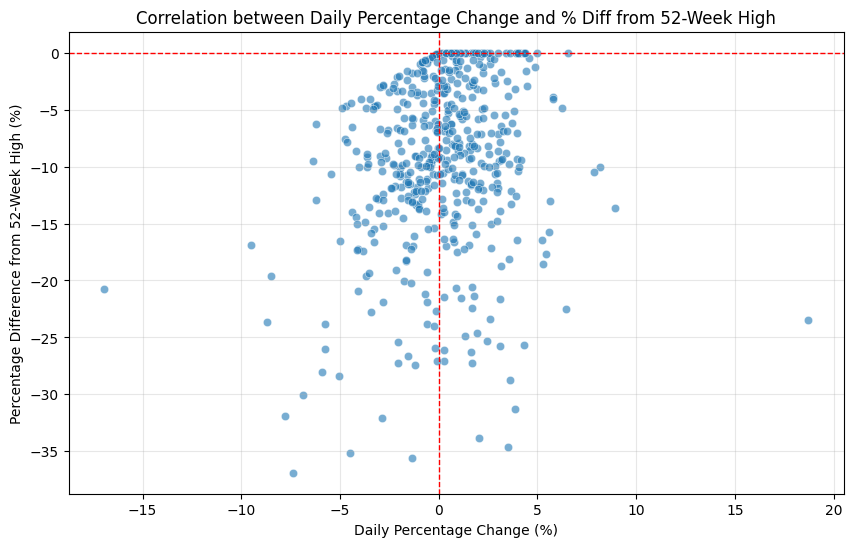

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the correlation between daily_pct_change and pct_diff_52w_high
plt.figure(figsize=(10, 6))
sns.scatterplot(data=stock_data, x='daily_pct_change', y='pct_diff_52w_high', alpha=0.6)
plt.title('Correlation between Daily Percentage Change and % Diff from 52-Week High')
plt.xlabel('Daily Percentage Change (%)')
plt.ylabel('Percentage Difference from 52-Week High (%)')
plt.axhline(0, color='red', linestyle='--', linewidth=1) # Add a line at 0 for reference
plt.axvline(0, color='red', linestyle='--', linewidth=1) # Add a line at 0 for reference
plt.grid(True, alpha=0.3)
plt.show()